# Machine Learning
## Sougui_DWH -  Ventes B2B

In [1]:
import os, warnings
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import mlflow
import mlflow.sklearn


warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)

COLORS = {
    "Random Forest":     "#1f77b4",
    "Gradient Boosting": "#ff7f0e",
    "XGBoost":           "#2ca02c",
    "accent":            "#d62728",
}
OUTPUT_DIR = "models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

ModuleNotFoundError: No module named 'mlflow'

## Phase 1 : Connexion SQL Server & Chargement

In [5]:
SQL_SERVER   = "localhost,1433"
SQL_DATABASE = "Sougui_DWH"
SQL_USER     = "sa"
SQL_PASSWORD = "admin"

conn_str = (
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SQL_SERVER};"
    f"DATABASE={SQL_DATABASE};"
    f"UID={SQL_USER};"
    f"PWD={SQL_PASSWORD};"
    f"TrustServerCertificate=yes;"
)

try:
    conn = pyodbc.connect(conn_str)
    print(f"Connexion réussie : {SQL_DATABASE}")
except Exception as e:
    raise ConnectionError(f"Connexion échouée : {e}")

Connexion réussie : Sougui_DWH


In [6]:
query = """
SELECT
    -- ===== FACT_VENTE_B2B =====
    f.Date_Key,
    f.Id_Entreprise,
    f.Id_Produit,
    f.Num_facture,
    f.Quantite,
    f.Prix_Total_HT,
    f.Montant_Total_HT,
    f.TVA,
    f.Timbre,
    f.Total_TTC,
    f.Type,
    -- ===== DIM_ENTREPRISE =====
    e.Nom                  AS Entreprise_Nom,
    e.Matricule_fiscal     AS Entreprise_Matricule,
    e.Adresse              AS Entreprise_Adresse,
    e.Latitude             AS Entreprise_Latitude,
    e.Longitude            AS Entreprise_Longitude,
    -- ===== DIM_PRODUIT_SOUGUI =====
    p.Reference            AS Produit_Reference,
    p.Description          AS Produit_Description,
    p.PU_HT                AS Produit_PU_HT,
    p.Nom                  AS Produit_Nom,
    p.Categorie            AS Produit_Categorie,
    p.Source               AS Produit_Source,
    p.Tarif_Regulier       AS Produit_Tarif_Regulier,
    p.Tarif_Promo          AS Produit_Tarif_Promo,
    p.En_Stock             AS Produit_En_Stock,
    -- ===== DIM_DATE =====
    d.Full_Date,
    d.Jour,
    d.Nom_Jour,
    d.Jour_Semaine,
    d.Semaine_Annee,
    d.Mois,
    d.Nom_Mois,
    d.Trimestre,
    d.Annee,
    d.Est_Weekend
FROM dbo.Fact_Vente_B2B      f
INNER JOIN dbo.Dim_Entreprise     e ON f.Id_Entreprise = e.Id_Client
INNER JOIN dbo.Dim_Produit_Sougui p ON f.Id_Produit    = p.Id_Produit
INNER JOIN dbo.Dim_Date           d ON f.Date_Key       = d.Date_Key
"""

df_raw = pd.read_sql(query, conn)

print(f"Données chargées : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"  Période : {df_raw['Annee'].min()}-{df_raw['Mois'].min():02d} "
      f" {df_raw['Annee'].max()}-{df_raw['Mois'].max():02d}")
df_raw.head()

Données chargées : 222 lignes × 35 colonnes
  Période : 2024-01  2026-12


,Date_Key,Id_Entreprise,Id_Produit,Num_facture,Quantite,Prix_Total_HT,Montant_Total_HT,TVA,Timbre,Total_TTC,...,Full_Date,Jour,Nom_Jour,Jour_Semaine,Semaine_Annee,Mois,Nom_Mois,Trimestre,Annee,Est_Weekend
0,20241025,293,1281,DEV24-19,450.0,14400.0,14400.0,2736.000000,1.0,17137.000000,...,2024-10-25,25,vendredi,5,43,10,octobre,4,2024,False
1,20241025,293,1282,DEV24-20,450.0,9900.0,9900.0,1881.000000,1.0,11782.000000,...,2024-10-25,25,vendredi,5,43,10,octobre,4,2024,False
2,20241025,293,1290,DEV24-18,450.0,14850.0,14850.0,2821.500000,1.0,17672.500000,...,2024-10-25,25,vendredi,5,43,10,octobre,4,2024,False
3,20241025,293,1317,DEV24-17,450.0,15750.0,15750.0,2992.500000,1.0,18743.500000,...,2024-10-25,25,vendredi,5,43,10,octobre,4,2024,False
4,20241025,304,1277,DEV24-16,432.0,26784.0,26784.0,5088.959961,1.0,31873.960938,...,2024-10-25,25,vendredi,5,43,10,octobre,4,2024,False


## Phase 2 : Compréhension des Données (EDA)

In [7]:
print(f"  Lignes totales        : {df_raw.shape[0]:,}")
print(f"  Produits uniques      : {df_raw['Id_Produit'].nunique():,}")
print(f"  Clients uniques       : {df_raw['Id_Entreprise'].nunique():,}")
print(f"  Références produit    : {df_raw['Produit_Reference'].nunique():,}")
print(f"  Types de documents    : {df_raw['Type'].unique().tolist()}")
print(f"  Catégories produit    : {df_raw['Produit_Categorie'].nunique():,}")
print()
print("Valeurs manquantes :")
missing = df_raw.isnull().sum()
print(missing[missing > 0].to_string())

  Lignes totales        : 222
  Produits uniques      : 62
  Clients uniques       : 17
  Références produit    : 59
  Types de documents    : ['Devis', 'Facture']
  Catégories produit    : 2

Valeurs manquantes :
Entreprise_Latitude       130
Entreprise_Longitude      130
Produit_Nom               214
Produit_Categorie         214
Produit_Source            220
Produit_Tarif_Regulier    216
Produit_Tarif_Promo       222
Produit_En_Stock          216


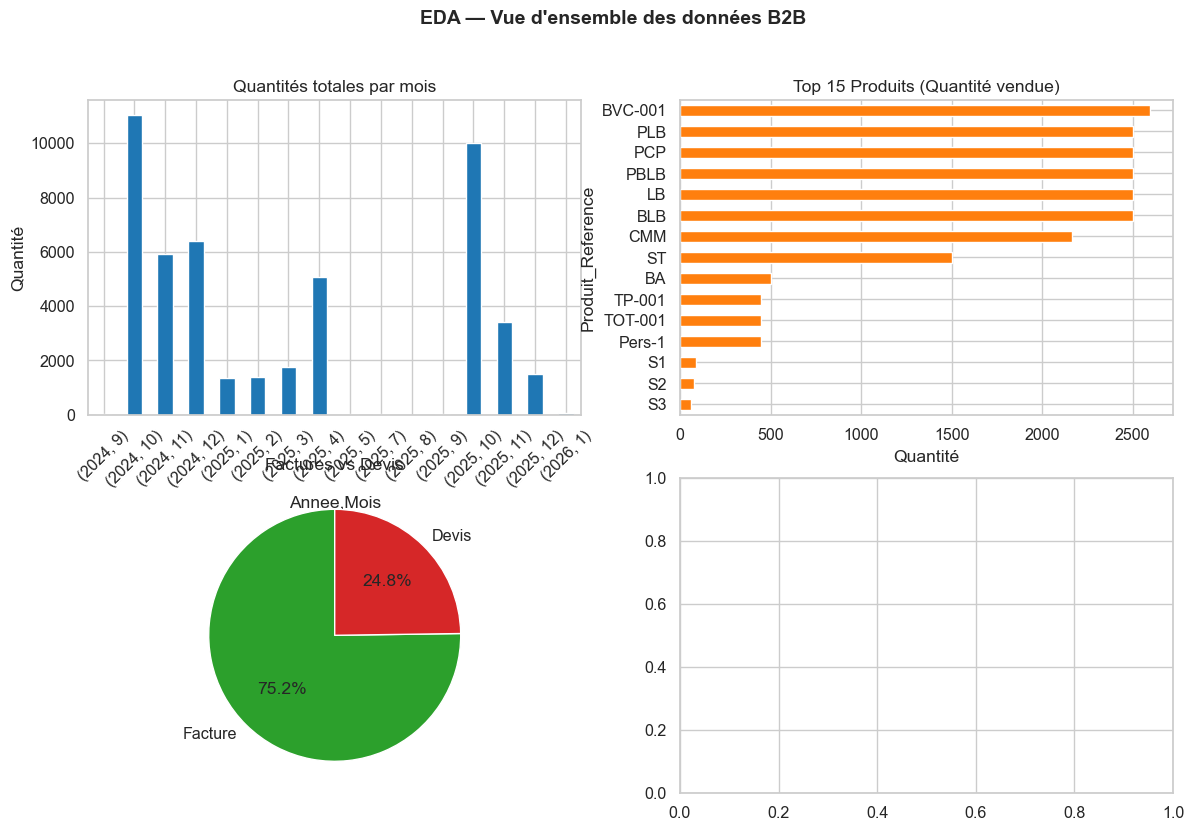

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("EDA — Vue d'ensemble des données B2B", fontsize=14, fontweight="bold")

# 1. Volume de ventes par mois
df_raw.groupby(["Annee", "Mois"])["Quantite"].sum().plot(
    kind="bar", ax=axes[0, 0], color="#1f77b4", edgecolor="white")
axes[0, 0].set_title("Quantités totales par mois")
axes[0, 0].set_ylabel("Quantité"); axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Top 15 produits
top_prod = (df_raw[df_raw["Type"] == "Facture"]
            .groupby("Produit_Reference")["Quantite"].sum()
            .nlargest(15).sort_values())
top_prod.plot(kind="barh", ax=axes[0, 1], color="#ff7f0e", edgecolor="white")
axes[0, 1].set_title("Top 15 Produits (Quantité vendue)")
axes[0, 1].set_xlabel("Quantité")

# 3. Répartition Facture vs Devis
df_raw["Type"].value_counts().plot(
    kind="pie", ax=axes[1, 0], autopct="%1.1f%%", colors=["#2ca02c", "#d62728"],
    startangle=90, wedgeprops={"edgecolor": "white"})
axes[1, 0].set_title("Factures vs Devis"); axes[1, 0].set_ylabel("")

plt.show()

## Phase 3 : Préparation des Données & Feature Engineering

In [10]:
df = df_raw.copy()
df["Full_Date"] = pd.to_datetime(df["Full_Date"], errors="coerce")

# Conserver uniquement les Factures réelles (pas les Devis)
df = df[df["Type"] == "Facture"].copy()
df = df[df["Quantite"] > 0].copy()

print(f"Après filtrage (Factures uniquement) : {df.shape[0]:,} lignes")

# Agrégation mensuelle par produit (unité de prévision)
df_agg = (
    df.groupby(
        ["Annee", "Mois", "Id_Produit", "Produit_Reference",
         "Produit_Description", "Produit_PU_HT", "Trimestre"]
    )
    .agg(
        Quantite_Totale = ("Quantite",      "sum"),
        Nb_Commandes    = ("Num_facture",   "nunique"),
        CA_HT           = ("Prix_Total_HT", "sum"),
        Nb_Clients      = ("Id_Entreprise", "nunique"),
    )
    .reset_index()
)

df_agg = df_agg.sort_values(["Id_Produit", "Annee", "Mois"]).reset_index(drop=True)
print(f"Dataset agrégé : {df_agg.shape[0]} observations (produit × mois)")

# Feature Engineering

# Lag features (demande passée par produit)
for lag in [1, 2, 3]:
    df_agg[f"Lag_{lag}"] = (
        df_agg.groupby("Id_Produit")["Quantite_Totale"].shift(lag)
    )

# Rolling mean 3 mois
df_agg["Rolling_Mean_3"] = (
    df_agg.groupby("Id_Produit")["Quantite_Totale"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Haute saison Q4 (oct–déc)
df_agg["Is_Q4"] = (df_agg["Trimestre"] == 4).astype(int)

# Encodage des variables catégorielles
le_ref  = LabelEncoder()
le_desc = LabelEncoder()
df_agg["Ref_Encoded"]  = le_ref.fit_transform(df_agg["Produit_Reference"].fillna("UNKNOWN"))
df_agg["Desc_Encoded"] = le_desc.fit_transform(df_agg["Produit_Description"].fillna("UNKNOWN"))

# Saisonnalité cyclique (mois)
df_agg["Mois_Sin"] = np.sin(2 * np.pi * df_agg["Mois"] / 12)
df_agg["Mois_Cos"] = np.cos(2 * np.pi * df_agg["Mois"] / 12)

# Supprimer les NaN créés par les lags
df_model = df_agg.dropna(subset=["Lag_1", "Lag_2", "Lag_3"]).copy()
print(f"Après feature engineering : {df_model.shape[0]} observations utilisables")

# Features & Target
FEATURES = [
    "Mois", "Annee", "Trimestre", "Is_Q4",
    "Mois_Sin", "Mois_Cos",
    "Ref_Encoded", "Desc_Encoded",
    "Produit_PU_HT",
    "Nb_Commandes", "Nb_Clients", "CA_HT",
    "Lag_1", "Lag_2", "Lag_3",
    "Rolling_Mean_3",
]
TARGET = "Quantite_Totale"

X = df_model[FEATURES]
y = df_model[TARGET]

# Split chronologique 80 / 20 
split_idx = int(len(df_model) * 0.80)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Split train/test : {len(X_train)} / {len(X_test)} (80% / 20% — chronologique)")
df_model[FEATURES + [TARGET]].describe()

Après filtrage (Factures uniquement) : 167 lignes
Dataset agrégé : 106 observations (produit × mois)
Après feature engineering : 29 observations utilisables
Split train/test : 23 / 6 (80% / 20% — chronologique)


,Mois,Annee,Trimestre,Is_Q4,Mois_Sin,Mois_Cos,Ref_Encoded,Desc_Encoded,Produit_PU_HT,Nb_Commandes,Nb_Clients,CA_HT,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Quantite_Totale
count,29.000000,29.000000,29.000000,29.000000,2.900000e+01,2.900000e+01,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,6.379310,2024.862069,2.448276,0.206897,9.420865e-02,-1.600350e-02,29.068966,30.275862,37.448276,1.689655,1.827586,221.586207,37.068966,37.034483,22.068966,32.057471,6.827586
std,3.488899,0.350931,1.120784,0.412251,7.847342e-01,6.406630e-01,4.780399,5.049021,6.162016,0.929802,0.889180,150.366580,159.107316,159.114398,78.972839,132.326918,4.751458
min,1.000000,2024.000000,1.000000,0.000000,-1.000000e+00,-8.660254e-01,7.000000,10.000000,32.000000,1.000000,1.000000,64.000000,2.000000,2.000000,3.000000,3.333333,2.000000
25%,3.000000,2025.000000,1.000000,0.000000,-8.660254e-01,-5.000000e-01,27.000000,29.000000,32.000000,1.000000,1.000000,128.000000,5.000000,5.000000,4.000000,6.000000,4.000000
50%,7.000000,2025.000000,3.000000,0.000000,-2.449294e-16,-1.836970e-16,30.000000,30.000000,40.000000,1.000000,2.000000,192.000000,7.000000,7.000000,7.000000,7.000000,6.000000
75%,9.000000,2025.000000,3.000000,0.000000,8.660254e-01,5.000000e-01,32.000000,31.000000,40.000000,2.000000,2.000000,224.000000,8.000000,8.000000,8.000000,9.333333,7.000000
max,12.000000,2025.000000,4.000000,1.000000,1.000000e+00,1.000000e+00,33.000000,40.000000,62.000000,4.000000,4.000000,640.000000,864.000000,864.000000,432.000000,720.000000,20.000000


## Phase 4 : Modélisation & GridSearchCV
Trois modèles sont entraînés et optimisés :
- **Random Forest** (ensemble bagging)
- **Gradient Boosting** (ensemble boosting sklearn)
- **XGBoost** (boosting optimisé)

In [11]:
# Helper : calcul des métriques 
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(
        np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))
    ) * 100
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


def train_and_evaluate(name, estimator, param_grid, X_tr, y_tr, X_te, y_te, cv=3):
    """GridSearch + évaluation complète. Retourne le meilleur modèle + dict métriques."""
    print(f"\n{'─'*55}")
    print(f"{name}")
    print(f"{'─'*55}")

    grid = GridSearchCV(
        estimator, param_grid,
        cv=cv, scoring="neg_mean_absolute_error",
        n_jobs=-1, verbose=0,
    )
    grid.fit(X_tr, y_tr)
    best = grid.best_estimator_

    print(f"  Meilleurs paramètres  : {grid.best_params_}")
    print(f"  MAE CV (train)        : {-grid.best_score_:.4f}")

    tr = compute_metrics(y_tr, best.predict(X_tr))
    te = compute_metrics(y_te, best.predict(X_te))

    print(f"  Train  →  MAE={tr['MAE']:.2f}  RMSE={tr['RMSE']:.2f}  "
          f"R²={tr['R2']:.4f}  MAPE={tr['MAPE']:.2f}%")
    print(f"  Test   →  MAE={te['MAE']:.2f}  RMSE={te['RMSE']:.2f}  "
          f"R²={te['R2']:.4f}  MAPE={te['MAPE']:.2f}%")

    return {
        "name":    name,
        "model":   best,
        "y_pred":  best.predict(X_te),
        "train":   tr,
        "test":    te,
        "params":  grid.best_params_,
    }

### Modèle 1 — Random Forest

In [12]:
rf_params = {
    "n_estimators":      [50, 100, 200, 300],
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

res_rf = train_and_evaluate(
    "Random Forest",
    RandomForestRegressor(random_state=42),
    rf_params,
    X_train, y_train, X_test, y_test,
)


───────────────────────────────────────────────────────
Random Forest
───────────────────────────────────────────────────────
  Meilleurs paramètres  : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  MAE CV (train)        : 1.4698
  Train  →  MAE=0.36  RMSE=0.49  R²=0.9902  MAPE=7.99%
  Test   →  MAE=0.66  RMSE=0.90  R²=0.7500  MAPE=23.56%


### Modèle 2 — Gradient Boosting

In [13]:
gb_params = {
    "n_estimators":   [100, 200, 300, 500],
    "learning_rate":  [0.01, 0.05, 0.1, 0.2],
    "max_depth":      [3, 5, 7],
    "subsample":      [0.7, 0.8, 1.0],
    "min_samples_split": [2, 5],
}

res_gb = train_and_evaluate(
    "Gradient Boosting",
    GradientBoostingRegressor(random_state=42),
    gb_params,
    X_train, y_train, X_test, y_test,
)


───────────────────────────────────────────────────────
Gradient Boosting
───────────────────────────────────────────────────────
  Meilleurs paramètres  : {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}
  MAE CV (train)        : 0.4056
  Train  →  MAE=0.00  RMSE=0.00  R²=1.0000  MAPE=0.00%
  Test   →  MAE=0.37  RMSE=0.47  R²=0.9301  MAPE=12.33%


### Modèle 3 — XGBoost

In [14]:
xgb_params = {
    "n_estimators":      [100, 200, 300, 500],
    "learning_rate":     [0.01, 0.05, 0.1, 0.2],
    "max_depth":         [3, 5, 7],
    "subsample":         [0.7, 0.8, 1.0],
    "colsample_bytree":  [0.7, 0.8, 1.0],
    "reg_alpha":         [0, 0.1, 0.5],
    "reg_lambda":        [1, 1.5, 2],
}

res_xgb = train_and_evaluate(
    "XGBoost",
    xgb.XGBRegressor(random_state=42, verbosity=0, eval_metric="mae"),
    xgb_params,
    X_train, y_train, X_test, y_test,
)

RESULTS = {
    "Random Forest":     res_rf,
    "Gradient Boosting": res_gb,
    "XGBoost":           res_xgb,
}


───────────────────────────────────────────────────────
XGBoost
───────────────────────────────────────────────────────
  Meilleurs paramètres  : {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 500, 'reg_alpha': 0.5, 'reg_lambda': 2, 'subsample': 1.0}
  MAE CV (train)        : 0.3616
  Train  →  MAE=0.04  RMSE=0.15  R²=0.9991  MAPE=1.20%
  Test   →  MAE=0.75  RMSE=0.93  R²=0.7292  MAPE=24.97%


## Phase 5 — Évaluation & Comparaison

In [15]:
def compare_models(results: dict) -> tuple:
    """
    Compare les modèles, affiche le tableau récapitulatif
    et retourne le nom + objet du meilleur modèle.
    """
    rows = []
    for name, r in results.items():
        rows.append({
            "Modèle":  name,
            "MAE":     round(r["test"]["MAE"],  4),
            "RMSE":    round(r["test"]["RMSE"], 4),
            "R²":      round(r["test"]["R2"],   4),
            "MAPE %":  round(r["test"]["MAPE"], 2),
        })
    df_cmp = pd.DataFrame(rows).set_index("Modèle")

    # Score composite : récompense R² élevé et MAE faible
    df_cmp["Score"] = df_cmp["R²"] - df_cmp["MAE"] / (df_cmp["MAE"].max() + 1e-9)

    print("\n" + "═" * 65)
    print("  TABLEAU COMPARATIF — JEU DE TEST")
    print("═" * 65)
    print(df_cmp.drop(columns="Score").to_string())
    print("═" * 65)

    best_name = df_cmp["Score"].idxmax()
    b = results[best_name]["test"]
    print(f"\n  MEILLEUR MODÈLE : {best_name} ")
    print(f"     R²={b['R2']:.4f} | MAE={b['MAE']:.4f} | "
          f"RMSE={b['RMSE']:.4f} | MAPE={b['MAPE']:.2f}%\n")

    return best_name, df_cmp


BEST_NAME, df_comparison = compare_models(RESULTS)


═════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF — JEU DE TEST
═════════════════════════════════════════════════════════════════
                      MAE    RMSE      R²  MAPE %
Modèle                                           
Random Forest      0.6626  0.8976  0.7500   23.56
Gradient Boosting  0.3706  0.4747  0.9301   12.33
XGBoost            0.7487  0.9342  0.7292   24.97
═════════════════════════════════════════════════════════════════

  MEILLEUR MODÈLE : Gradient Boosting 
     R²=0.9301 | MAE=0.3706 | RMSE=0.4747 | MAPE=12.33%



### Visualisations — Évaluation complète

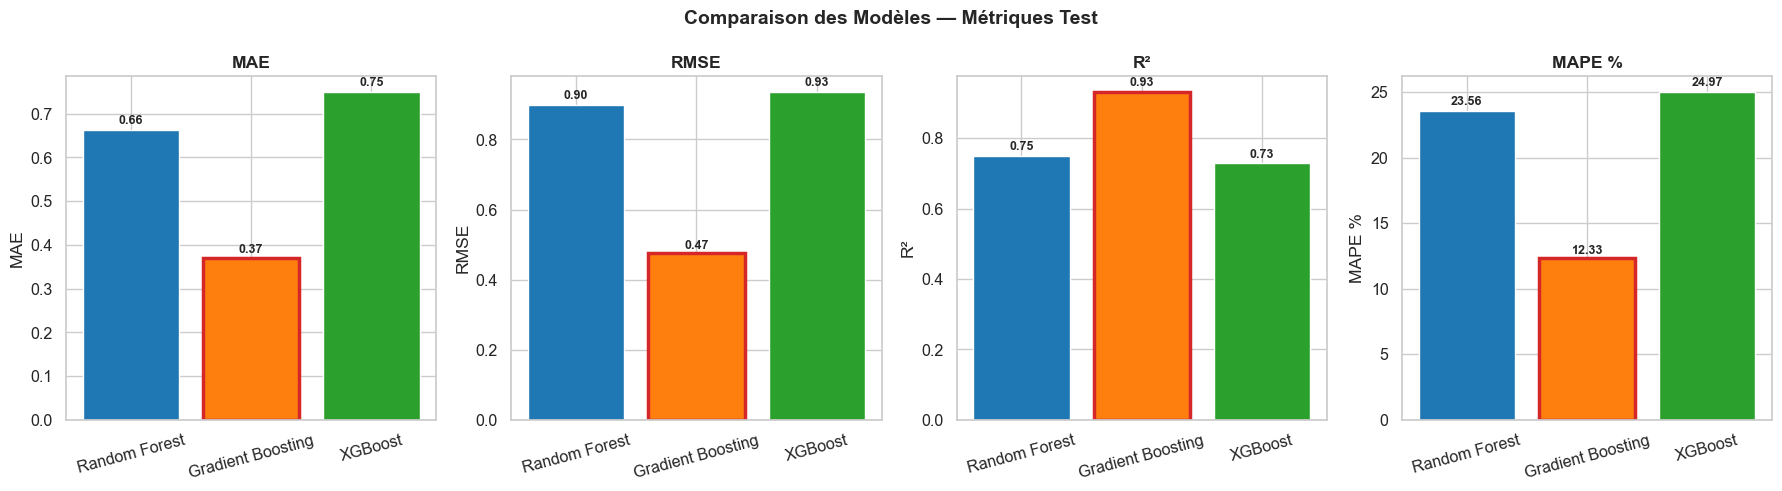

In [16]:
# ── Fig 1 : Comparaison des métriques ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Comparaison des Modèles — Métriques Test", fontsize=14, fontweight="bold")

metric_pairs = [("MAE","MAE"),("RMSE","RMSE"),("R²","R²"),("MAPE %","MAPE %")]
for ax, (col, label) in zip(axes, metric_pairs):
    vals  = df_comparison[col].tolist()
    names = list(df_comparison.index)
    cols  = [COLORS[n] for n in names]
    bars  = ax.bar(names, vals, color=cols, edgecolor="white")
    ax.set_title(label, fontweight="bold"); ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    # Encadrer le meilleur
    idx = names.index(BEST_NAME)
    bars[idx].set_edgecolor(COLORS["accent"]); bars[idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/../1_comparaison_metriques.png", dpi=130, bbox_inches="tight")
plt.show()

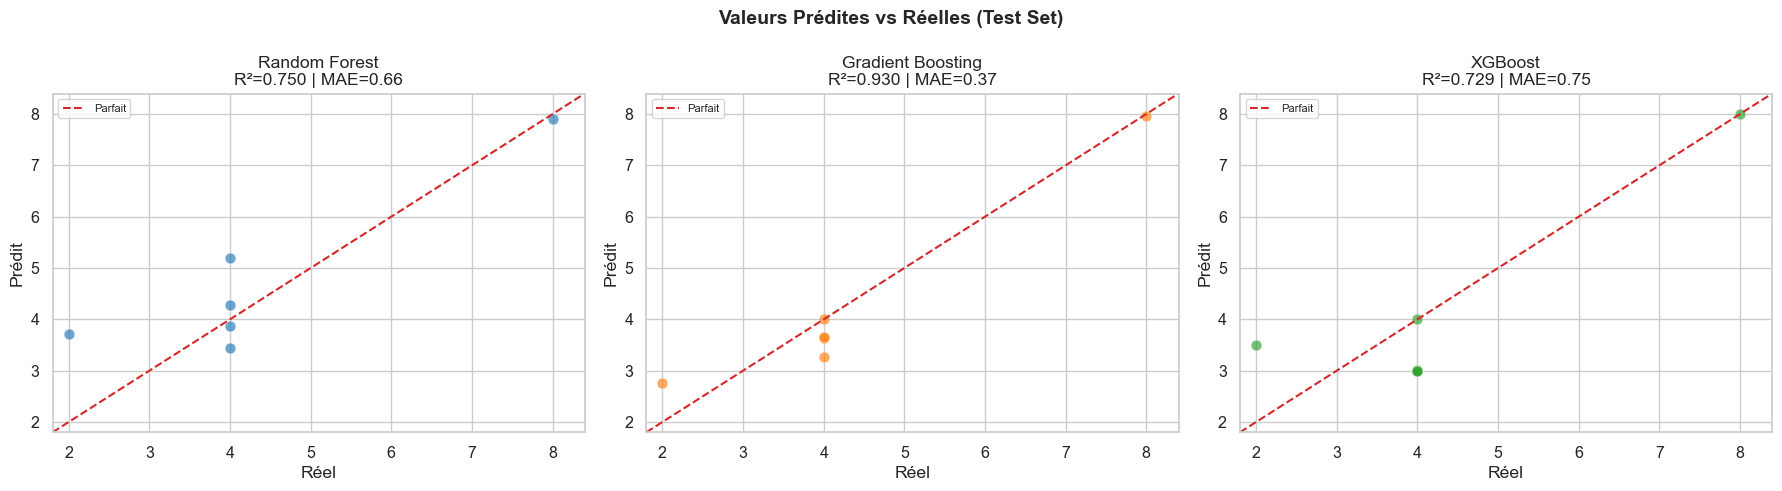

In [15]:
# Prédictions vs Réel
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Valeurs Prédites vs Réelles (Test Set)", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes, RESULTS.items()):
    y_pred = res["y_pred"]
    ax.scatter(y_test, y_pred, alpha=0.65, color=COLORS[name], s=60,
               edgecolors="white", linewidths=0.4)
    lims = [min(y_test.min(), y_pred.min())*0.9,
            max(y_test.max(), y_pred.max())*1.05]
    ax.plot(lims, lims, "--", color=COLORS["accent"], linewidth=1.5, label="Parfait")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Réel"); ax.set_ylabel("Prédit")
    ax.set_title(f"{name}\nR²={res['test']['R2']:.3f} | MAE={res['test']['MAE']:.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/../2_pred_vs_reel.png", dpi=130, bbox_inches="tight")
plt.show()

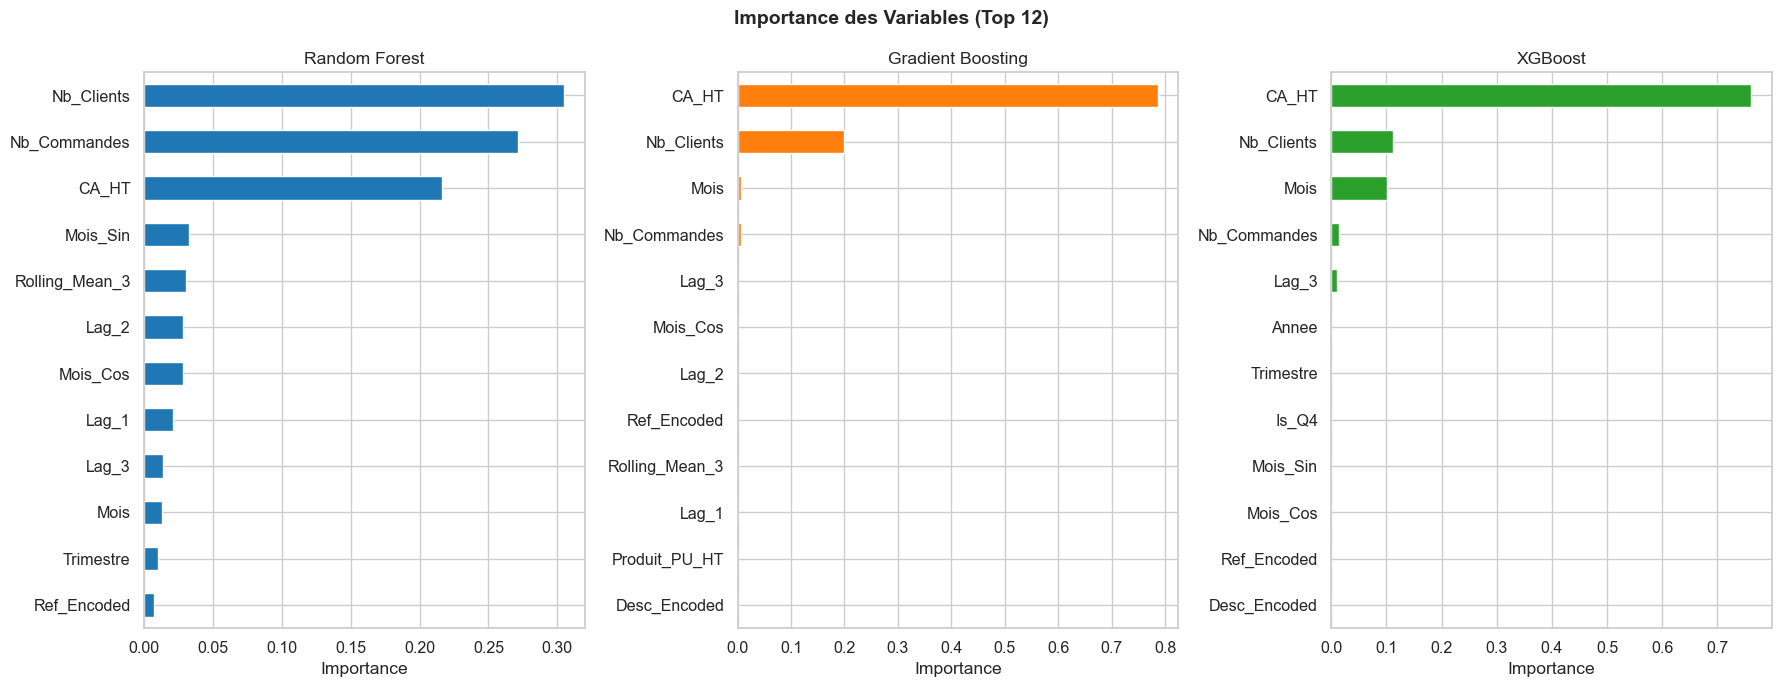

In [17]:
# Fig 4 : Importance des variables
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Importance des Variables (Top 12)", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes, RESULTS.items()):
    imp = pd.Series(res["model"].feature_importances_, index=FEATURES).nlargest(12)
    imp[::-1].plot(kind="barh", ax=ax, color=COLORS[name], edgecolor="white")
    ax.set_title(name); ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/../4_feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

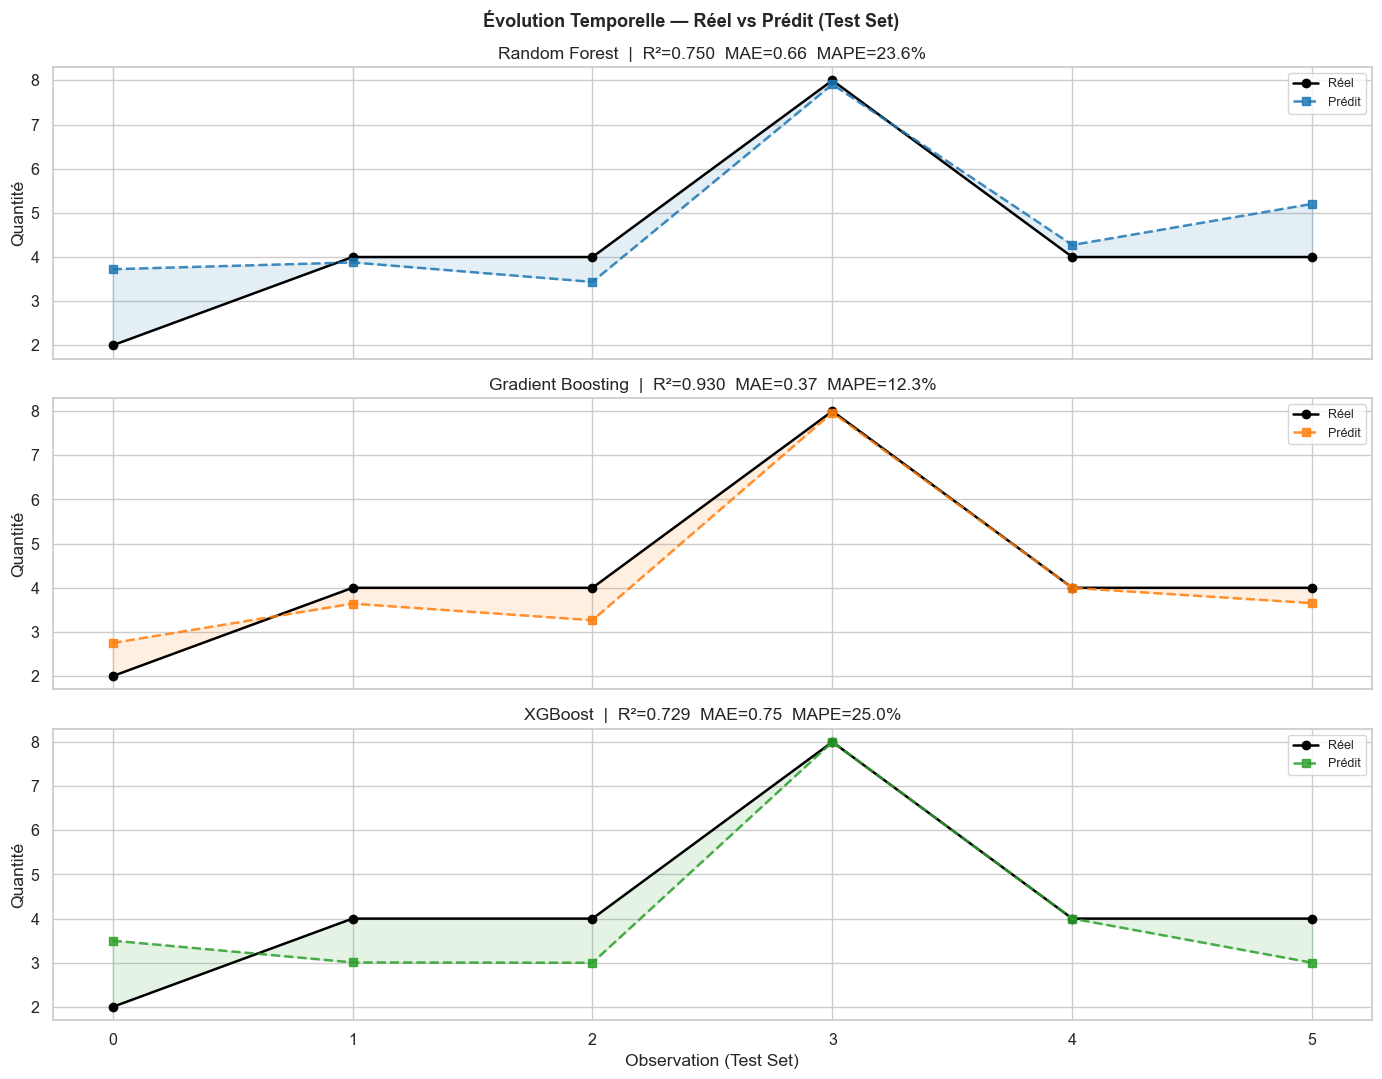

In [19]:
# Fig 6 : Évolution temporelle
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle("Évolution Temporelle — Réel vs Prédit (Test Set)",
             fontsize=13, fontweight="bold")

for ax, (name, res) in zip(axes, RESULTS.items()):
    ax.plot(range(len(y_test)), y_test.values, "o-", label="Réel",
            color="black", linewidth=1.8, markersize=6)
    ax.plot(range(len(y_test)), res["y_pred"], "s--", label="Prédit",
            color=COLORS[name], linewidth=1.8, markersize=6, alpha=0.85)
    ax.fill_between(range(len(y_test)), y_test.values, res["y_pred"],
                    alpha=0.12, color=COLORS[name])
    ax.set_title(
        f"{name}  |  R²={res['test']['R2']:.3f}  "
        f"MAE={res['test']['MAE']:.2f}  MAPE={res['test']['MAPE']:.1f}%"
    )
    ax.set_ylabel("Quantité"); ax.legend(fontsize=9)

axes[-1].set_xlabel("Observation (Test Set)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/../6_serie_temporelle.png", dpi=130, bbox_inches="tight")
plt.show()

## Phase 6 — Export des modèles `.pkl`

In [20]:
# Sauvegarder chaque modèle
joblib.dump(res_rf["model"],  f"{OUTPUT_DIR}/model_random_forest.pkl",     compress=3)
joblib.dump(res_gb["model"],  f"{OUTPUT_DIR}/model_gradient_boosting.pkl", compress=3)
joblib.dump(res_xgb["model"], f"{OUTPUT_DIR}/model_xgboost.pkl",           compress=3)

# Sauvegarder le meilleur modèle
best_model_obj = RESULTS[BEST_NAME]["model"]
joblib.dump(best_model_obj,  f"{OUTPUT_DIR}/best_model.pkl",               compress=3)

# Sauvegarder les encodeurs et la liste des features (requis en production)
joblib.dump(le_ref,   f"{OUTPUT_DIR}/encoder_produit_reference.pkl")
joblib.dump(le_desc,  f"{OUTPUT_DIR}/encoder_produit_description.pkl")
joblib.dump(FEATURES, f"{OUTPUT_DIR}/feature_list.pkl")

print("- Modèles sauvegardés dans le dossier 'models/' :")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1024
    print(f"   {f:<45} {size:>8.1f} KB")

✔ Modèles sauvegardés dans le dossier 'models/' :
   best_model.pkl                                    24.4 KB
   encoder_produit_description.pkl                    1.4 KB
   encoder_produit_reference.pkl                      0.8 KB
   feature_list.pkl                                   0.2 KB
   model_gradient_boosting.pkl                       24.4 KB
   model_random_forest.pkl                           22.4 KB
   model_xgboost.pkl                                 35.3 KB


## Prédiction sur une nouvelle observation

In [21]:
def predict_demand(
    annee: int,
    mois: int,
    produit_reference: str,
    produit_description: str,
    produit_pu_ht: float,
    nb_commandes: int,
    nb_clients: int,
    ca_ht: float,
    lag_1: float,
    lag_2: float,
    lag_3: float,
    rolling_mean_3: float,
    model=None,
) -> float:
    """
    Prédit la quantité demandée pour un produit sur un mois donné.
    Si model=None, utilise le meilleur modèle entraîné dans la session.

    Exemple :
    ---------
    qty = predict_demand(
        annee=2026, mois=4,
        produit_reference='BLB',
        produit_description='Bourse Lunch box personnalisé',
        produit_pu_ht=7.0,
        nb_commandes=3, nb_clients=2, ca_ht=7400.0,
        lag_1=480.0, lag_2=500.0, lag_3=480.0, rolling_mean_3=486.7
    )
    """
    if model is None:
        model = best_model_obj

    trimestre = (mois - 1) // 3 + 1
    is_q4     = int(trimestre == 4)

    try:
        ref_enc = le_ref.transform([produit_reference])[0]
    except ValueError:
        ref_enc = 0   # Label inconnu → 0

    try:
        desc_enc = le_desc.transform([produit_description])[0]
    except ValueError:
        desc_enc = 0

    row = pd.DataFrame([{
        "Mois": mois, "Annee": annee, "Trimestre": trimestre, "Is_Q4": is_q4,
        "Mois_Sin": np.sin(2 * np.pi * mois / 12),
        "Mois_Cos": np.cos(2 * np.pi * mois / 12),
        "Ref_Encoded": ref_enc, "Desc_Encoded": desc_enc,
        "Produit_PU_HT": produit_pu_ht,
        "Nb_Commandes": nb_commandes, "Nb_Clients": nb_clients, "CA_HT": ca_ht,
        "Lag_1": lag_1, "Lag_2": lag_2, "Lag_3": lag_3,
        "Rolling_Mean_3": rolling_mean_3,
    }])[FEATURES]

    return max(0.0, float(model.predict(row)[0]))

In [22]:
# Exemple d'utilisation 
qty = predict_demand(
    annee=2026, mois=4,
    produit_reference="BLB",
    produit_description="Bourse Lunch box personnalisé",
    produit_pu_ht=7.0,
    nb_commandes=3, nb_clients=2, ca_ht=7400.0,
    lag_1=480.0, lag_2=500.0, lag_3=480.0, rolling_mean_3=486.7,
)

print(f" Quantité prédite (Avril 2026 | BLB — Bourse Lunch box) : {qty:.0f} unités")
print(f"     Modèle utilisé : {BEST_NAME}")

 Quantité prédite (Avril 2026 | BLB — Bourse Lunch box) : 17 unités
     Modèle utilisé : Gradient Boosting


In [ ]:
mlflow.set_experiment("Sougui_B2B_Sales")

In [ ]:
with mlflow.start_run(run_name="GradientBoosting"):

    gb = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    gb.fit(X_train, y_train)

    y_pred = gb.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 5)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2", r2)

    mlflow.sklearn.log_model(gb, "gradient_boosting_model")